In [1]:
# ==========================================
# PHASE 1: KERNEL SVM (7 vs Not 7)
# SETUP & IMPORTS
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Scikit-Learn (Data Handling, Modeling, and Evaluation)
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-Image (Image Processing and Feature Extraction)
from skimage.feature import hog
from skimage.transform import resize

# Set a random seed so your results are reproducible!
np.random.seed(42)

# Set default plotting style for images
plt.rc('image', cmap='gray')

print("Environment setup complete. All libraries imported!")

Environment setup complete. All libraries imported!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# 1. Download MNIST (This might take 1-2 minutes the first time you run it)
print("Downloading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

# 2. Create our Binary Target
# We want '1' if the image is a 7, and '-1' if it is anything else
y_binary = np.where(y == '7', 1, -1)

print(f"Total images loaded: {X.shape[0]}")
print(f"Pixels per image: {X.shape[1]} (This is a flattened 28x28 image)")

Total images loaded: 70000
Pixels per image: 784 (This is a flattened 28x28 image)


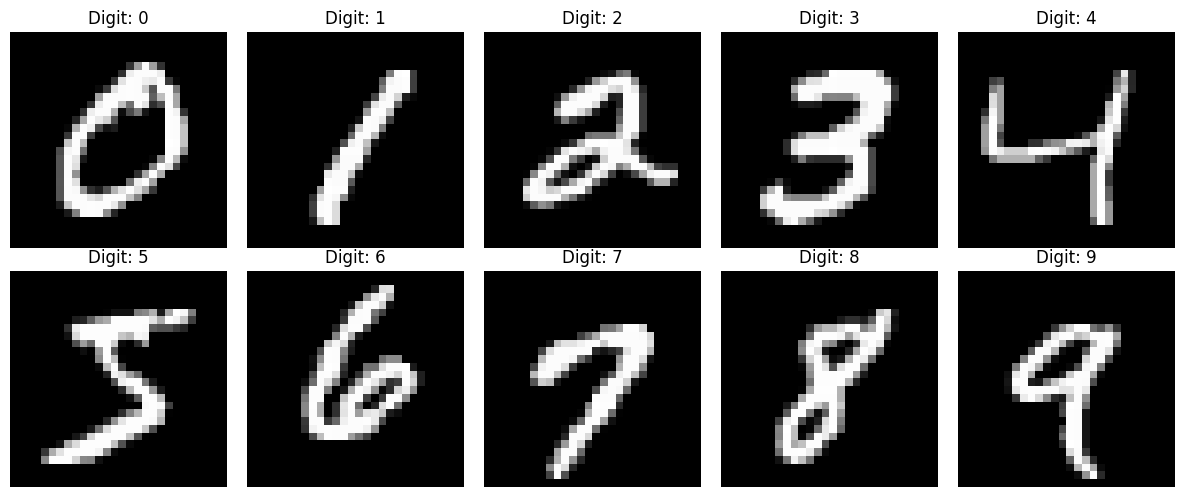

In [3]:
# Create a figure with a 2x5 grid (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten() # Flatten the 2D axes array to easily loop over it

for digit in range(10):
    # Find the index of the first image that matches the current digit (0-9)
    # y is currently an array of strings, so we convert the digit to a string
    idx = np.where(y == str(digit))[0][0]

    # Reshape the flat 784-item array back into a 28x28 grid
    img = X[idx].reshape(28, 28)

    # Plot it in grayscale
    axes[digit].imshow(img, cmap='gray')
    axes[digit].set_title(f"Digit: {digit}")
    axes[digit].axis('off')

plt.tight_layout()
plt.show()

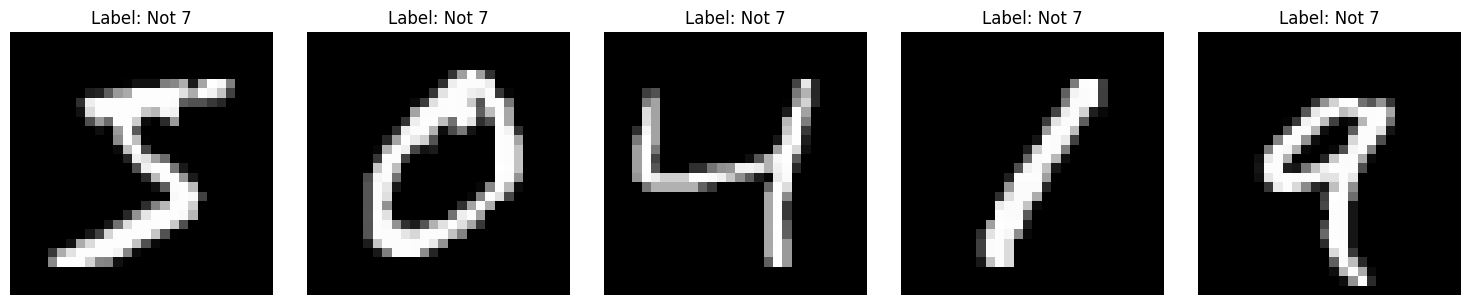

In [4]:
# Create a figure to hold 5 plots side-by-side
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    # Reshape the flat 784-item array back into a 28x28 grid
    img = X[i].reshape(28, 28)

    # Plot it in grayscale
    ax.imshow(img, cmap='gray')

    # Add a title showing our binary label
    label = "7" if y_binary[i] == 1 else "Not 7"
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

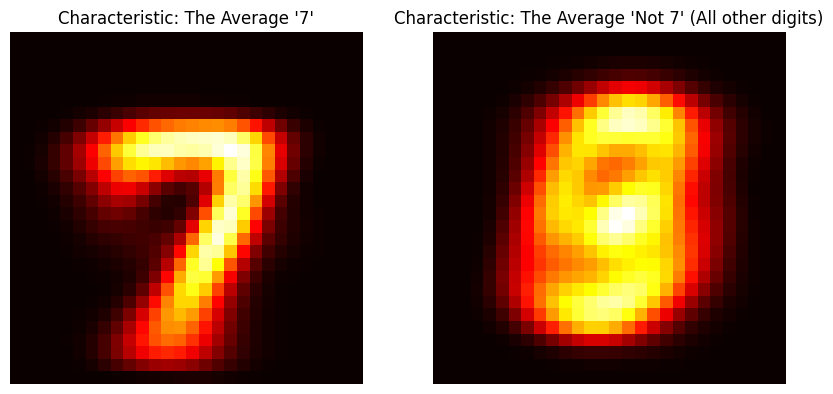

In [5]:
# Isolate all the 7s and all the Not 7s
sevens = X[y_binary == 1]
not_sevens = X[y_binary == -1]

# Calculate the average pixel values across all images in each group
avg_seven = np.mean(sevens, axis=0).reshape(28, 28)
avg_not_seven = np.mean(not_sevens, axis=0).reshape(28, 28)

# Plot them side by side using a 'hot' color map to show intensity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(avg_seven, cmap='hot')
ax1.set_title("Characteristic: The Average '7'")
ax1.axis('off')

ax2.imshow(avg_not_seven, cmap='hot')
ax2.set_title("Characteristic: The Average 'Not 7' (All other digits)")
ax2.axis('off')

plt.show()

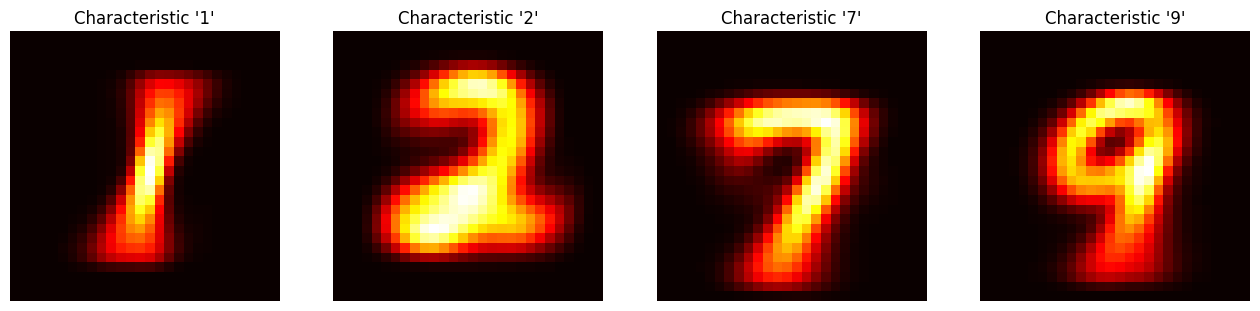

In [6]:
# Calculate the average pixel values for the specific digits
# We filter X based on the original label 'y', take the mean, and reshape to 28x28
avg_1 = np.mean(X[y == '1'], axis=0).reshape(28, 28)
avg_2 = np.mean(X[y == '2'], axis=0).reshape(28, 28)
avg_7 = np.mean(X[y == '7'], axis=0).reshape(28, 28)
avg_9 = np.mean(X[y == '9'], axis=0).reshape(28, 28)

# Create a figure to hold 4 plots side-by-side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Bundle them into lists so we can loop through them easily
averages = [avg_1, avg_2, avg_7, avg_9]
labels = ["Characteristic '1'", "Characteristic '2'", "Characteristic '7'", "Characteristic '9'"]

for i in range(4):
    axes[i].imshow(averages[i], cmap='hot')
    axes[i].set_title(labels[i])
    axes[i].axis('off')

plt.show()

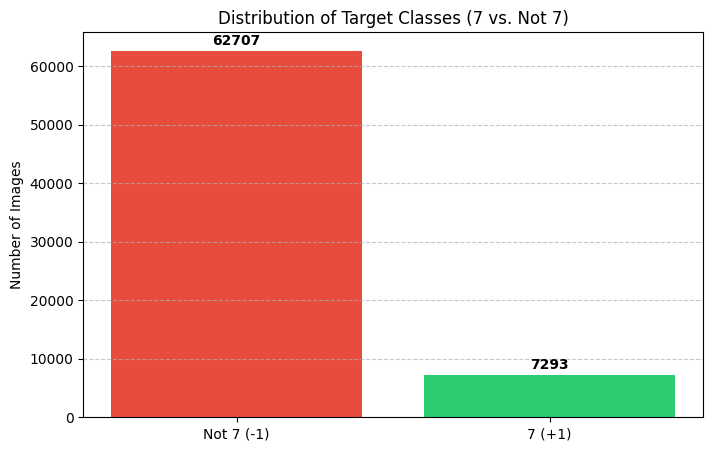

Percentage of '7's in dataset: 10.42%
Percentage of 'Not 7's in dataset: 89.58%


In [7]:
# ==========================================
# CHECKING CLASS IMBALANCE
# ==========================================

# Count how many of each class we have
unique_classes, class_counts = np.unique(y_binary, return_counts=True)

# Create a bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(['Not 7 (-1)', '7 (+1)'], class_counts, color=['#e74c3c', '#2ecc71'])

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{yval}', ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Target Classes (7 vs. Not 7)')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print out the exact ratio
total_samples = len(y_binary)
ratio_7 = (class_counts[1] / total_samples) * 100
print(f"Percentage of '7's in dataset: {ratio_7:.2f}%")
print(f"Percentage of 'Not 7's in dataset: {100 - ratio_7:.2f}%")

In [8]:
# 3. MASTER SPLIT (80% Train/Val Pool, 20% Final Test)
# We use stratify=y_binary to ensure the 90/10 ratio is preserved in the test set.
X_train_val_pool, X_final_test, y_train_val_pool, y_final_test = train_test_split(
    X, y_binary, test_size=0.20, random_state=42, stratify=y_binary
)

# 4. SUBSETTING (Extracting 10,000 images from the 56,000 Training Pool)
# This keeps the experiment efficient while staying representative.
subset_ratio = 10000 / len(X_train_val_pool)
X_subset, _, y_subset, _ = train_test_split(
    X_train_val_pool, y_train_val_pool, train_size=subset_ratio, random_state=42, stratify=y_train_val_pool
)

# 5. TRAIN/VALIDATION SPLIT (75% Train, 25% Validation from our 10k subset)
X_train, X_val, y_train, y_val = train_test_split(
    X_subset, y_subset, test_size=0.25, random_state=42, stratify=y_subset
)

# --- Summary ---
print("\n--- Data Integrity Check ---")
print(f"Final Test Set (Reserved): {len(X_final_test)} samples")
print(f"Training Subset:           {len(X_train)} samples")
print(f"Validation Subset:         {len(X_val)} samples")
print(f"Target Ratio in Train:     {(y_train == 1).mean()*100:.1f}% are '7's")


--- Data Integrity Check ---
Final Test Set (Reserved): 14000 samples
Training Subset:           7500 samples
Validation Subset:         2500 samples
Target Ratio in Train:     10.4% are '7's


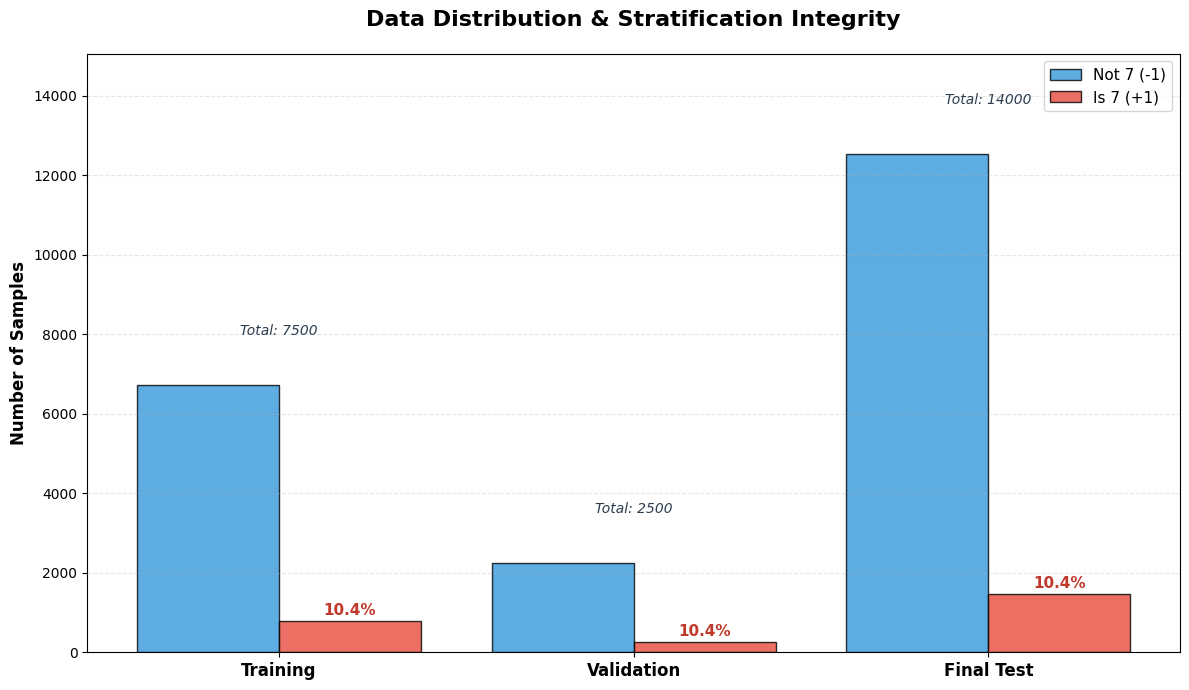

In [9]:
import matplotlib.pyplot as plt

# 1. Prepare data for the plot
set_names = ['Training', 'Validation', 'Final Test']
class_neg = [np.sum(y_train == -1), np.sum(y_val == -1), np.sum(y_final_test == -1)]
class_pos = [np.sum(y_train == 1), np.sum(y_val == 1), np.sum(y_final_test == 1)]
totals = [len(y_train), len(y_val), len(y_final_test)]

# 2. Setup the figure
x = np.arange(len(set_names))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 7))

# Create grouped bars
bar1 = ax.bar(x - width/2, class_neg, width, label='Not 7 (-1)', color='#3498db', edgecolor='black', alpha=0.8)
bar2 = ax.bar(x + width/2, class_pos, width, label='Is 7 (+1)', color='#e74c3c', edgecolor='black', alpha=0.8)

# 3. Add Titles and Labels
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Data Distribution & Stratification Integrity', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(set_names, fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Add Percentage Annotations (The "Proof" of Stratification)
for i in range(len(set_names)):
    # Calculate percentage for the '7' class
    percentage = (class_pos[i] / totals[i]) * 100

    # Place text above the 'Is 7' bar
    ax.text(i + width/2, class_pos[i] + (max(class_pos) * 0.05),
            f'{percentage:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#c0392b')

    # Also add total sample count labels above each set group
    ax.text(i, max(class_neg[i], class_pos[i]) + (max(class_neg) * 0.1),
            f'Total: {totals[i]}',
            ha='center', fontsize=10, style='italic', color='#2c3e50')

plt.ylim(0, max(class_neg) * 1.2) # Give some space for labels
plt.tight_layout()
plt.show()

Extracting HOG features for Training Set (7500 samples)...
Extracting HOG features for Validation Set (2500 samples)...
Extracting HOG features for Final Test Set (14000 samples)...

HOG Extraction Complete!
Original Feature Count: 784 (Pixels)
HOG Feature Count:      324 (Gradients)


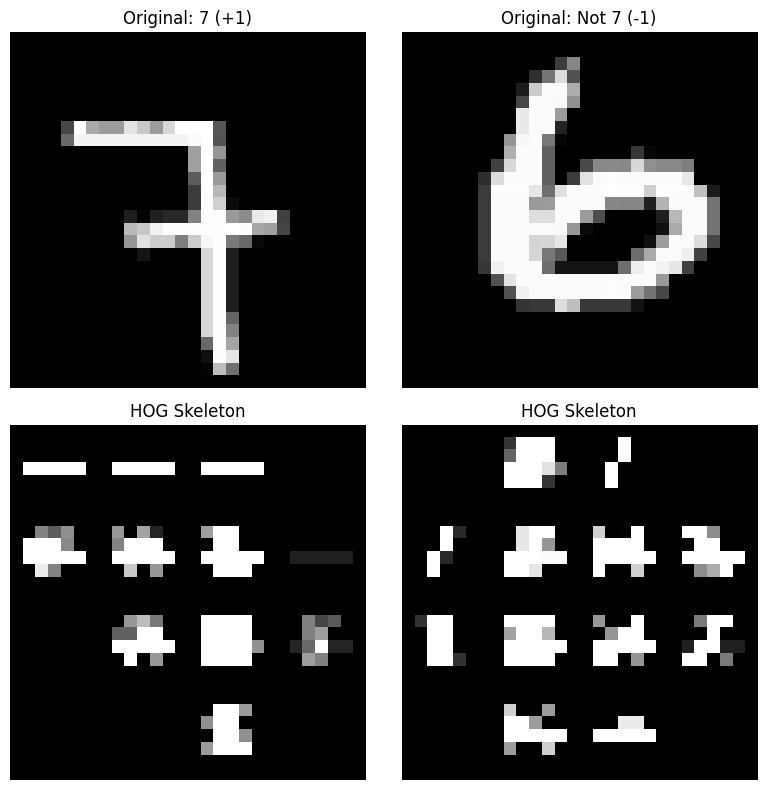

In [10]:
# ==========================================
# PHASE 2: DATA PROCESSING
# Step 2: HOG Feature Extraction (28x28)
# ==========================================
from skimage.feature import hog
from skimage import exposure

def process_hog_pipeline(X_data, name="Dataset"):
    """
    Reshapes 1D MNIST data to 2D and extracts HOG features.
    Using: 9 orientations, 7x7 pixels per cell, 2x2 cells per block.
    """
    print(f"Extracting HOG features for {name} ({len(X_data)} samples)...")
    hog_features = []

    for i in range(len(X_data)):
        # 1. Reshape from 784 to 28x28
        img_2d = X_data[i].reshape(28, 28)

        # 2. Extract HOG Feature Descriptor (fd)
        # We use visualize=False for bulk processing to save memory
        fd = hog(img_2d, orientations=9, pixels_per_cell=(7, 7),
                 cells_per_block=(2, 2), visualize=False)

        hog_features.append(fd)

    return np.array(hog_features)

# --- Execute Extraction ---
X_train_hog = process_hog_pipeline(X_train, "Training Set")
X_val_hog   = process_hog_pipeline(X_val,   "Validation Set")
X_test_hog  = process_hog_pipeline(X_final_test, "Final Test Set")

print(f"\nHOG Extraction Complete!")
print(f"Original Feature Count: 784 (Pixels)")
print(f"HOG Feature Count:      {X_train_hog.shape[1]} (Gradients)")

# --- VISUALIZATION CHECK ---
# Let's verify the HOG "Skeleton" for a '7' and a 'Not 7'
idx_7 = np.where(y_train == 1)[0][0]
idx_not_7 = np.where(y_train == -1)[0][0]
demo_indices = [idx_7, idx_not_7]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for i, idx in enumerate(demo_indices):
    img = X_train[idx].reshape(28, 28)
    # Generate visualization for these two samples only
    fd, hog_viz = hog(img, orientations=9, pixels_per_cell=(7, 7),
                      cells_per_block=(2, 2), visualize=True)

    # Rescale for better display
    hog_viz_rescaled = exposure.rescale_intensity(hog_viz, in_range=(0, 10))

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"Original: {'7 (+1)' if y_train[idx]==1 else 'Not 7 (-1)'}")
    axes[0, i].axis('off')

    axes[1, i].imshow(hog_viz_rescaled, cmap='gray')
    axes[1, i].set_title("HOG Skeleton")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# PHASE 2: DATA PROCESSING
# Step 3: Manual Feature Scaling
# ==========================================

import numpy as np

print("Initializing Manual StandardScaler...")

# ==========================================
# 1. COMPUTE MEAN AND STD FROM TRAINING SET
# ==========================================

train_mean = np.mean(X_train_hog, axis=0)
train_std = np.std(X_train_hog, axis=0)

# Prevent division by zero
train_std[train_std == 0] = 1

# ==========================================
# 2. SCALE TRAINING DATA
# ==========================================

X_train_scaled = (
    X_train_hog - train_mean
) / train_std

# ==========================================
# 3. SCALE VALIDATION DATA
# Using TRAIN statistics only
# ==========================================

X_val_scaled = (
    X_val_hog - train_mean
) / train_std

# ==========================================
# 4. SCALE TEST DATA
# Using TRAIN statistics only
# ==========================================

X_test_scaled = (
    X_test_hog - train_mean
) / train_std

print("Feature Scaling Complete!")

# ==========================================
# SANITY CHECK
# ==========================================

print("\n--- Scaling Sanity Check ---")

print(
    f"Training Mean (Should be ~0): "
    f"{X_train_scaled.mean():.16f}"
)

print(
    f"Training Std (Should be ~1):  "
    f"{X_train_scaled.std():.4f}"
)

print(
    f"\nValidation Mean (Close to 0): "
    f"{X_val_scaled.mean():.4f}"
)

print(
    f"Validation Std (Close to 1):  "
    f"{X_val_scaled.std():.4f}"
)

print(
    f"\nTest Set Mean (Close to 0):   "
    f"{X_test_scaled.mean():.4f}"
)

print(
    f"Test Set Std (Close to 1):    "
    f"{X_test_scaled.std():.4f}"
)

Initializing Manual StandardScaler...
Feature Scaling Complete!

--- Scaling Sanity Check ---
Training Mean (Should be ~0): -0.0000000000000001
Training Std (Should be ~1):  1.0000

Validation Mean (Close to 0): -0.0034
Validation Std (Close to 1):  1.0016

Test Set Mean (Close to 0):   0.0002
Test Set Std (Close to 1):    1.0019


In [12]:
!pip install qpsolvers
import numpy as np
from scipy.spatial.distance import cdist
from qpsolvers import solve_qp

class ManualSVM:
    def __init__(self, C=1.0, gamma='scale', class_weight=None):
        self.C = C
        self.gamma = gamma
        self.class_weight = class_weight
        self.alpha = None
        self.b = 0

    def _compute_gamma(self, X):
        if self.gamma == 'scale':
            self.gamma_value = 1 / (X.shape[1] * np.var(X))
        else:
            self.gamma_value = self.gamma
        return self.gamma_value

    def rbf_kernel(self, X1, X2):
        gamma = self.gamma_value
        sq_dists = cdist(X1, X2, 'sqeuclidean')
        return np.exp(-gamma * sq_dists)

    def _compute_class_weights(self, y):
        if self.class_weight == 'balanced':
            n = len(y)
            classes = np.unique(y)
            weights = {}
            for c in classes:
                weights[c] = n / (len(classes) * np.sum(y == c))
            return weights
        return {1: 1.0, -1: 1.0}

    def fit(self, X, y):
        n = len(y)

        # Store gamma ONCE (important!)
        self._compute_gamma(X)

        # Kernel matrix
        K = self.rbf_kernel(X, X)

        # Build QP matrices
        Y = y.reshape(-1,1) * y.reshape(1,-1)
        P = K * Y + np.eye(n) * 1e-8   # smaller regularization
        q = -np.ones(n)

        A = y.astype(float)
        b = np.array([0.0])

        lb = np.zeros(n)

        # Class weights
        weights = self._compute_class_weights(y)
        C_i = np.array([self.C * weights[label] for label in y])

        # Solve QP
        self.alpha = solve_qp(P, q, A=A, b=b, lb=lb, ub=C_i, solver="osqp")

        if self.alpha is None:
            raise ValueError("QP solver failed")

        # Support vectors
        sv_mask = self.alpha > 1e-6
        self.alpha_sv = self.alpha[sv_mask]
        self.X_sv = X[sv_mask]
        self.y_sv = y[sv_mask]

        # margin support vectors (for bias)
        margin_mask = (self.alpha > 1e-6) & (self.alpha < C_i - 1e-6)

        # Compute bias
        b_sum = 0
        count = 0

        for i in range(n):
            if margin_mask[i]:
                K_i = self.rbf_kernel(X, X[i].reshape(1,-1)).flatten()
                pred = np.sum(self.alpha * y * K_i)
                b_sum += y[i] - pred
                count += 1

        # Fallback if no margin SV found
        if count == 0:
            for i in range(len(self.alpha_sv)):
                K_i = self.rbf_kernel(self.X_sv, self.X_sv[i].reshape(1,-1)).flatten()
                pred = np.sum(self.alpha_sv * self.y_sv * K_i)
                b_sum += self.y_sv[i] - pred
            self.b = b_sum / len(self.alpha_sv)
        else:
            self.b = b_sum / count

        print(f"Support vectors: {len(self.alpha_sv)}")
        print(f"Bias b: {self.b:.4f}")

    def predict(self, X):
        K = self.rbf_kernel(self.X_sv, X)
        decision = np.dot(self.alpha_sv * self.y_sv, K) + self.b
        return np.sign(decision)


Training Manual SVM for Variant A (with balanced class weights)...


/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


Support vectors: 1312
Bias b: -0.7593
========== MANUAL EVALUATION (Variant A) ==========
Accuracy  : 0.9888
Precision : 0.9496
Recall    : 0.9423
F1-Score  : 0.9459

Confusion Matrix:
[[2227   13]
 [  15  245]]


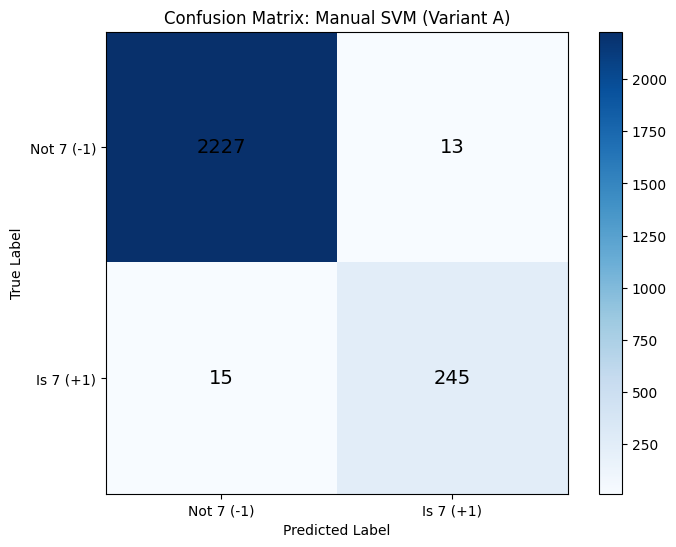

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PHASE 3: MODEL IMPLEMENTATION
# Variant A: Manual SVM with Class Weights
# ==========================================

# Instantiate and train the ManualSVM for Variant A
svm_manual = ManualSVM(C=1.0, gamma='scale', class_weight='balanced')
print("\nTraining Manual SVM for Variant A (with balanced class weights)...")
svm_manual.fit(X_train_scaled, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred_val = svm_manual.predict(X_val_scaled)

# ==========================================
# MANUAL CONFUSION MATRIX VALUES
# ==========================================

TP = np.sum((y_val == 1) & (y_pred_val == 1))
TN = np.sum((y_val == -1) & (y_pred_val == -1))
FP = np.sum((y_val == -1) & (y_pred_val == 1))
FN = np.sum((y_val == 1) & (y_pred_val == -1))

# ==========================================
# MANUAL METRICS
# ==========================================

accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0

recall = TP / (TP + FN) if (TP + FN) != 0 else 0

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) != 0 else 0
)

# ==========================================
# PRINT RESULTS
# ==========================================

print("========== MANUAL EVALUATION (Variant A) ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1_score:.4f}")

print("\nConfusion Matrix:")
print(np.array([[TN, FP],
                [FN, TP]]))

# ==========================================
# MANUAL CONFUSION MATRIX PLOT
# ==========================================

cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap='Blues')

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(['Not 7 (-1)', 'Is 7 (+1)'])
ax.set_yticklabels(['Not 7 (-1)', 'Is 7 (+1)'])

# Text inside cells
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha='center',
                va='center',
                color='black',
                fontsize=14)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_title("Confusion Matrix: Manual SVM (Variant A)")

plt.colorbar(im)
plt.show()

Manual Undersampling Complete.
New Training Size: 1564 (50/50 split)


/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


Support vectors: 477
Bias b: -0.3199

========== Variant B: Manual Evaluation ==========
Accuracy  : 0.9728
Precision : 0.8097
Recall    : 0.9654
F1-Score  : 0.8807

Confusion Matrix:
[[2181   59]
 [   9  251]]


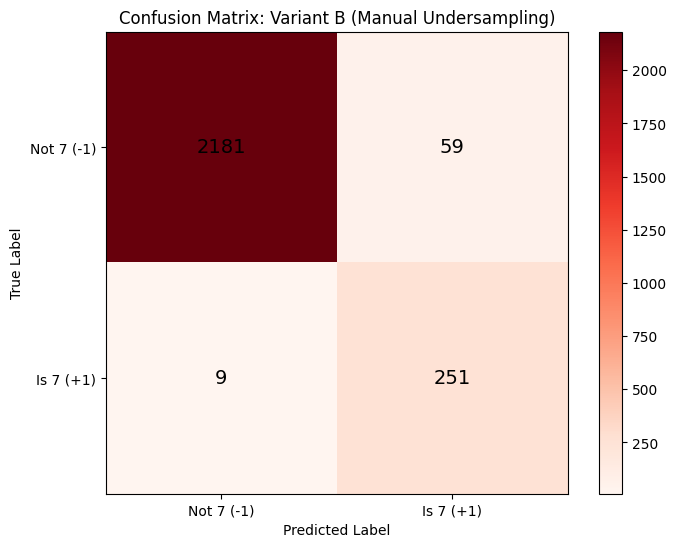

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. MANUAL UNDERSAMPLING
# ==========================================

# Get indices of each class
idx_pos = np.where(y_train == 1)[0]
idx_neg = np.where(y_train == -1)[0]

# Set random seed for reproducibility
np.random.seed(42)

# Randomly choose negative samples
idx_neg_undersampled = np.random.choice(
    idx_neg,
    size=len(idx_pos),
    replace=False
)

# Combine positive + sampled negative indices
idx_balanced = np.concatenate([
    idx_pos,
    idx_neg_undersampled
])

# Shuffle dataset
np.random.shuffle(idx_balanced)

# Create balanced dataset
X_train_undersampled = X_train_scaled[idx_balanced]
y_train_undersampled = y_train[idx_balanced]

print("Manual Undersampling Complete.")

print(
    f"New Training Size: "
    f"{len(y_train_undersampled)} (50/50 split)"
)

# ==========================================
# 2. TRAIN MANUAL SVM
# ==========================================

svm_manual_b = ManualSVM(
    C=1.0,
    gamma='scale',
    class_weight=None
)

svm_manual_b.fit(
    X_train_undersampled,
    y_train_undersampled
)

# ==========================================
# 3. PREDICTIONS
# ==========================================

y_pred_val_b = svm_manual_b.predict(X_val_scaled)

# ==========================================
# 4. MANUAL CONFUSION MATRIX VALUES
# ==========================================

TP = np.sum((y_val == 1) & (y_pred_val_b == 1))

TN = np.sum((y_val == -1) & (y_pred_val_b == -1))

FP = np.sum((y_val == -1) & (y_pred_val_b == 1))

FN = np.sum((y_val == 1) & (y_pred_val_b == -1))

# ==========================================
# 5. MANUAL METRICS
# ==========================================

accuracy = (
    (TP + TN) /
    (TP + TN + FP + FN)
)

precision = (
    TP / (TP + FP)
    if (TP + FP) != 0 else 0
)

recall = (
    TP / (TP + FN)
    if (TP + FN) != 0 else 0
)

f1_score = (
    2 * precision * recall /
    (precision + recall)
    if (precision + recall) != 0 else 0
)

# ==========================================
# 6. PRINT RESULTS
# ==========================================

print("\n========== Variant B: Manual Evaluation ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1_score:.4f}")

# ==========================================
# 7. MANUAL CONFUSION MATRIX
# ==========================================

cm_b = np.array([
    [TN, FP],
    [FN, TP]
])

print("\nConfusion Matrix:")
print(cm_b)

# ==========================================
# 8. PLOT CONFUSION MATRIX
# ==========================================

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm_b, cmap='Reds')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    'Not 7 (-1)',
    'Is 7 (+1)'
])

ax.set_yticklabels([
    'Not 7 (-1)',
    'Is 7 (+1)'
])

# Add numbers inside cells
for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            cm_b[i, j],
            ha='center',
            va='center',
            fontsize=14,
            color='black'
        )

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_title(
    "Confusion Matrix: Variant B (Manual Undersampling)"
)

plt.colorbar(im)

plt.show()

Applying Manual SMOTE...
Minority Samples Before: 782
Synthetic Samples Needed: 2577
Manual SMOTE Complete.
New Training Size: 10077 samples
Class Distribution:
{np.float64(-1.0): np.int64(6718), np.float64(1.0): np.int64(3359)}

Training Manual SVM on SMOTE data...


/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


Support vectors: 1287
Bias b: -0.8817

========== Variant C: Manual Evaluation ==========
Accuracy  : 0.9900
Precision : 0.9608
Recall    : 0.9423
F1-Score  : 0.9515

Confusion Matrix:
[[2230   10]
 [  15  245]]


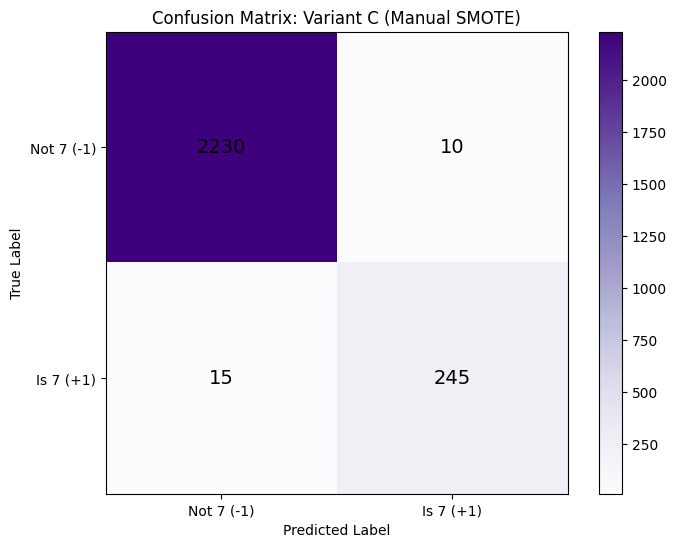

In [15]:
# ==========================================
# PHASE 3: MODEL IMPLEMENTATION
# Variant C: MANUAL SMOTE
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. MANUAL SMOTE
# ==========================================

print("Applying Manual SMOTE...")

# Minority (+1) and majority (-1)
X_minority = X_train_scaled[y_train == 1]
X_majority = X_train_scaled[y_train == -1]

y_minority = y_train[y_train == 1]
y_majority = y_train[y_train == -1]

minority_count = len(X_minority)
majority_count = len(X_majority)

# ==========================================
# TARGET RATIO = 0.5
# minority / majority = 0.5
# ==========================================

target_minority_count = int(0.5 * majority_count)

synthetic_needed = (
    target_minority_count - minority_count
)

print(f"Minority Samples Before: {minority_count}")
print(f"Synthetic Samples Needed: {synthetic_needed}")

# ==========================================
# GENERATE SYNTHETIC SAMPLES
# ==========================================

np.random.seed(42)

synthetic_samples = []

for _ in range(synthetic_needed):

    # Pick random minority sample
    idx1 = np.random.randint(0, minority_count)

    x1 = X_minority[idx1]

    # Find distances to all minority points
    distances = np.linalg.norm(
        X_minority - x1,
        axis=1
    )

    # Remove itself
    distances[idx1] = np.inf

    # Get 3 nearest neighbors
    neighbor_indices = np.argsort(distances)[:3]

    # Pick one random neighbor
    idx2 = np.random.choice(neighbor_indices)

    x2 = X_minority[idx2]

    # Random interpolation
    alpha = np.random.rand()

    synthetic_point = (
        x1 + alpha * (x2 - x1)
    )

    synthetic_samples.append(synthetic_point)

# Convert to array
synthetic_samples = np.array(synthetic_samples)

# ==========================================
# BUILD FINAL SMOTE DATASET
# ==========================================

X_train_smote = np.vstack([
    X_train_scaled,
    synthetic_samples
])

y_train_smote = np.concatenate([
    y_train,
    np.ones(synthetic_needed)
])

print("Manual SMOTE Complete.")

print(
    f"New Training Size: "
    f"{len(y_train_smote)} samples"
)

# Class distribution
unique, counts = np.unique(
    y_train_smote,
    return_counts=True
)

print("Class Distribution:")
print(dict(zip(unique, counts)))

# ==========================================
# 2. TRAIN MANUAL SVM
# ==========================================

svm_manual_c = ManualSVM(
    C=0.8,
    gamma='scale',
    class_weight=None
)

print("\nTraining Manual SVM on SMOTE data...")

svm_manual_c.fit(
    X_train_smote,
    y_train_smote
)

# ==========================================
# 3. PREDICTIONS
# ==========================================

y_pred_val_c = svm_manual_c.predict(
    X_val_scaled
)

# ==========================================
# 4. MANUAL CONFUSION MATRIX VALUES
# ==========================================

TP = np.sum(
    (y_val == 1) &
    (y_pred_val_c == 1)
)

TN = np.sum(
    (y_val == -1) &
    (y_pred_val_c == -1)
)

FP = np.sum(
    (y_val == -1) &
    (y_pred_val_c == 1)
)

FN = np.sum(
    (y_val == 1) &
    (y_pred_val_c == -1)
)

# ==========================================
# 5. MANUAL METRICS
# ==========================================

accuracy = (
    (TP + TN) /
    (TP + TN + FP + FN)
)

precision = (
    TP / (TP + FP)
    if (TP + FP) != 0 else 0
)

recall = (
    TP / (TP + FN)
    if (TP + FN) != 0 else 0
)

f1_score = (
    2 * precision * recall /
    (precision + recall)
    if (precision + recall) != 0 else 0
)

# ==========================================
# 6. PRINT RESULTS
# ==========================================

print("\n========== Variant C: Manual Evaluation ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1_score:.4f}")

# ==========================================
# 7. MANUAL CONFUSION MATRIX
# ==========================================

cm_c = np.array([
    [TN, FP],
    [FN, TP]
])

print("\nConfusion Matrix:")
print(cm_c)

# ==========================================
# 8. PLOT CONFUSION MATRIX
# ==========================================

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm_c, cmap='Purples')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    'Not 7 (-1)',
    'Is 7 (+1)'
])

ax.set_yticklabels([
    'Not 7 (-1)',
    'Is 7 (+1)'
])

# Add numbers inside cells
for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            cm_c[i, j],
            ha='center',
            va='center',
            fontsize=14,
            color='black'
        )

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_title(
    "Confusion Matrix: Variant C (Manual SMOTE)"
)

plt.colorbar(im)

plt.show()

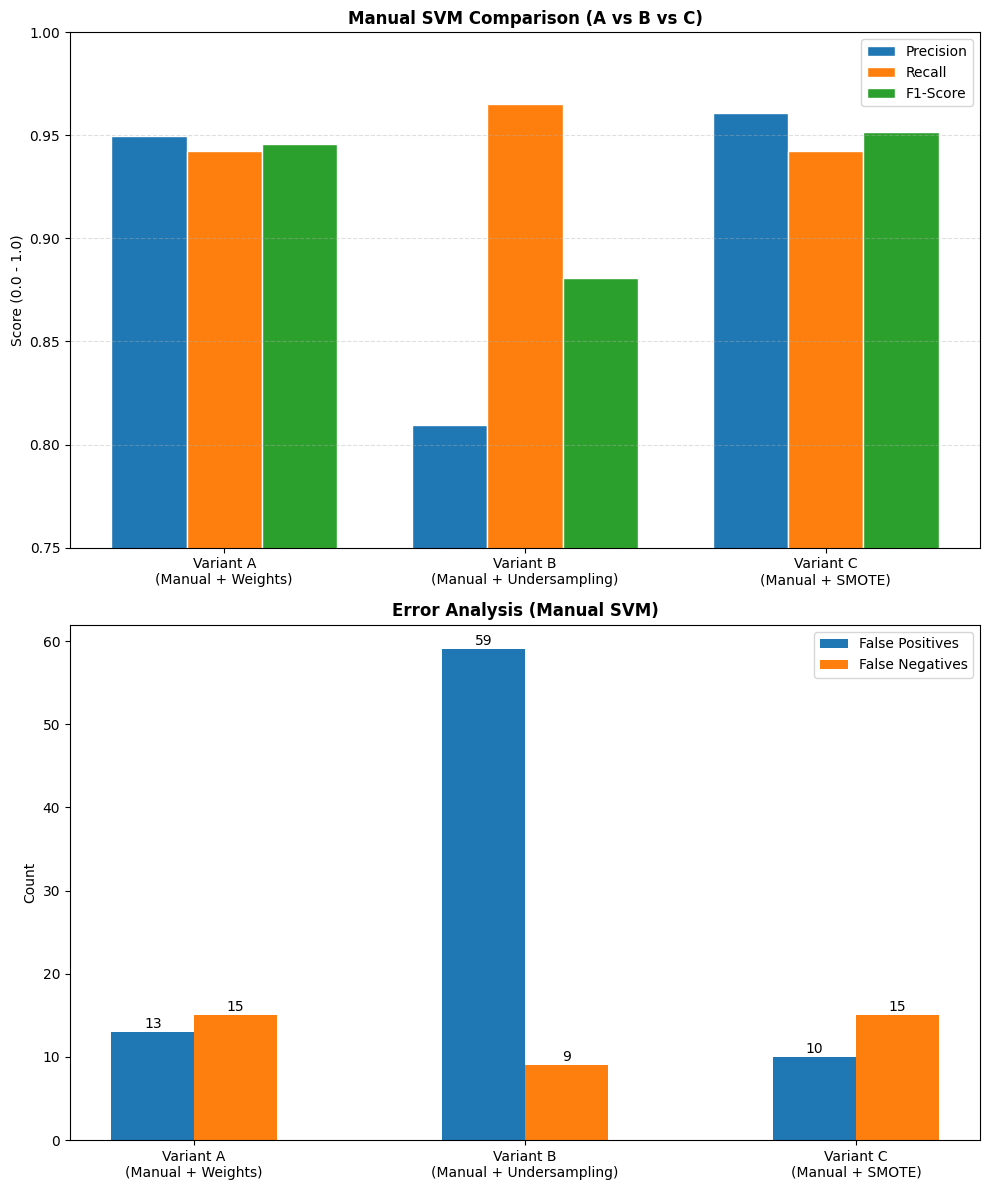

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Use ONLY Manual SVM predictions
# ==========================================

# y_pred_val      -> Variant A
# y_pred_val_b    -> Variant B
# y_pred_val_c    -> Variant C

all_predictions = [
    y_pred_val,
    y_pred_val_b,
    y_pred_val_c
]

model_labels = [
    'Variant A\n(Manual + Weights)',
    'Variant B\n(Manual + Undersampling)',
    'Variant C\n(Manual + SMOTE)'
]

# ==========================================
# MANUAL METRIC STORAGE
# ==========================================

precisions = []
recalls = []
f1s = []

false_positives = []
false_negatives = []

# ==========================================
# MANUAL METRIC CALCULATION
# ==========================================

for pred in all_predictions:

    # Confusion Matrix Values
    TP = np.sum((y_val == 1) & (pred == 1))
    TN = np.sum((y_val == -1) & (pred == -1))
    FP = np.sum((y_val == -1) & (pred == 1))
    FN = np.sum((y_val == 1) & (pred == -1))

    # Store Errors
    false_positives.append(FP)
    false_negatives.append(FN)

    # Manual Precision
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0

    # Manual Recall
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    # Manual F1
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) != 0 else 0
    )

    # Store Metrics
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)

# ==========================================
# PLOT COMPARISON
# ==========================================

x = np.arange(len(model_labels))
width = 0.25

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 12)
)

# ==========================================
# SCORE COMPARISON
# ==========================================

ax1.bar(
    x - width,
    precisions,
    width,
    label='Precision',
    edgecolor='white'
)

ax1.bar(
    x,
    recalls,
    width,
    label='Recall',
    edgecolor='white'
)

ax1.bar(
    x + width,
    f1s,
    width,
    label='F1-Score',
    edgecolor='white'
)

ax1.set_ylabel('Score (0.0 - 1.0)')

ax1.set_title(
    'Manual SVM Comparison (A vs B vs C)',
    fontweight='bold'
)

ax1.set_xticks(x)
ax1.set_xticklabels(model_labels)

ax1.set_ylim(0.75, 1.0)

ax1.legend()

ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# ==========================================
# ERROR ANALYSIS
# ==========================================

ax2.bar(
    x - width/2,
    false_positives,
    width,
    label='False Positives'
)

ax2.bar(
    x + width/2,
    false_negatives,
    width,
    label='False Negatives'
)

ax2.set_ylabel('Count')

ax2.set_title(
    'Error Analysis (Manual SVM)',
    fontweight='bold'
)

ax2.set_xticks(x)
ax2.set_xticklabels(model_labels)

ax2.legend()

# ==========================================
# ADD VALUES ON TOP OF BARS
# ==========================================

for i in range(len(model_labels)):

    ax2.text(
        x[i] - width/2,
        false_positives[i] + 0.5,
        str(int(false_positives[i])),
        ha='center'
    )

    ax2.text(
        x[i] + width/2,
        false_negatives[i] + 0.5,
        str(int(false_negatives[i])),
        ha='center'
    )

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# PHASE 5: FINAL TEST EVALUATION
# Manual SVM Only (NO sklearn.metrics)
# ==========================================

import numpy as np

print("Starting Final Inference on Test Set (Manual SVM)...")

# ==========================================
# 1. PREDICTIONS
# ==========================================

y_test_pred_a = svm_manual.predict(X_test_scaled)
y_test_pred_b = svm_manual_b.predict(X_test_scaled)
y_test_pred_c = svm_manual_c.predict(X_test_scaled)

# ==========================================
# 2. ORGANIZE RESULTS
# ==========================================

test_variants = {
    "Variant A (Manual + Weights)": y_test_pred_a,
    "Variant B (Manual + Undersampling)": y_test_pred_b,
    "Variant C (Manual + SMOTE)": y_test_pred_c
}

# ==========================================
# 3. MANUAL EVALUATION
# ==========================================

for name, preds in test_variants.items():

    print(f"\n{'-'*50}")
    print(f" FINAL PERFORMANCE: {name}")
    print(f"{'-'*50}")

    # ======================================
    # MANUAL CONFUSION MATRIX VALUES
    # ======================================

    TP = np.sum((y_final_test == 1) & (preds == 1))
    TN = np.sum((y_final_test == -1) & (preds == -1))
    FP = np.sum((y_final_test == -1) & (preds == 1))
    FN = np.sum((y_final_test == 1) & (preds == -1))

    # ======================================
    # MANUAL METRICS
    # ======================================

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = (
        TP / (TP + FP)
        if (TP + FP) != 0 else 0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) != 0 else 0
    )

    f1_score = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) != 0 else 0
    )

    # ======================================
    # MANUAL CONFUSION MATRIX
    # ======================================

    cm = np.array([
        [TN, FP],
        [FN, TP]
    ])

    # ======================================
    # PRINT RESULTS
    # ======================================

    print("\nEvaluation Metrics:")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1_score:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    # ======================================
    # ERROR ANALYSIS
    # ======================================

    print(f"\nTotal Test Samples: {len(y_final_test)}")

    print(f"Correct '7' Detections (TP): {TP}")

    print(f"Missed '7's (FN / Type II Error): {FN}")

    print(f"Wrongly Labeled as '7' (FP / Type I Error): {FP}")

    print(f"Correct Non-'7' Predictions (TN): {TN}")

Starting Final Inference on Test Set (Manual SVM)...

--------------------------------------------------
 FINAL PERFORMANCE: Variant A (Manual + Weights)
--------------------------------------------------

Evaluation Metrics:
Accuracy  : 0.9893
Precision : 0.9612
Recall    : 0.9349
F1-Score  : 0.9479

Confusion Matrix:
[[12486    55]
 [   95  1364]]

Total Test Samples: 14000
Correct '7' Detections (TP): 1364
Missed '7's (FN / Type II Error): 95
Wrongly Labeled as '7' (FP / Type I Error): 55
Correct Non-'7' Predictions (TN): 12486

--------------------------------------------------
 FINAL PERFORMANCE: Variant B (Manual + Undersampling)
--------------------------------------------------

Evaluation Metrics:
Accuracy  : 0.9759
Precision : 0.8246
Recall    : 0.9760
F1-Score  : 0.8939

Confusion Matrix:
[[12238   303]
 [   35  1424]]

Total Test Samples: 14000
Correct '7' Detections (TP): 1424
Missed '7's (FN / Type II Error): 35
Wrongly Labeled as '7' (FP / Type I Error): 303
Correct Non-